In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Model without substance 

In [33]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  
        
        mm = 0

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        fx = vx
        fy = vy

        # dt(x) = active * vx  #Change position acording to constant speed afected by forces
        # dt(y) = active * vy  
        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end


        # #Periodic boundry
        # xmin, xmax = simBox[1,1]*0.9, simBox[1,2]*0.9
        # ymin, ymax = simBox[2,1]*0.9, simBox[2,2]*0.9
        # # X direction
        # if x < xmin
        #     x += (xmax - xmin)
        # elseif x > xmax
        #     x -= (xmax - xmin)
        # end

        # # Y direction
        # if y < ymin
        #     y += (ymax - ymin)
        # elseif y > ymax
        #     y -= (ymax - ymin)
        # end

        #Previous boundry conditions
        # if x < simBox[1,1]*0.9
        #     x = simBox[1,1]*0.9
        #     theta = pi - theta   
        # elseif x > simBox[1,2]*0.9
        #     x = simBox[1,2]*0.9
        #     theta = pi - theta
        # end
        # if y < simBox[2,1]*0.9
        #     y = simBox[2,1]*0.9
        #     theta = -theta/2
        # elseif y > simBox[2,2]*0.9
        #     y = simBox[2,2]*0.9
        #     theta = -theta/2
        # end

    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if ac

In [34]:
com = Community(
    fixed_source,
    N=100,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 10
com.delta = 0.01

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.x = 2.5*sqrt(com.DMedium/com.delta)
com.y = 2.5*sqrt(com.DMedium/com.delta)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K 

com.S .= 0.0



100-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [35]:
outfile = "calculate_msd.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=100)

jldopen(outfile, "w") do file
    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
    end
end


In [22]:
jldopen("calculate_msd.jld2", "r") do file
    g = file[@sprintf("step_%06d", 1)]
    x = g["x"]
    println(size(x))
end


(200,)


Loading trajectories...
Done loading.
Computing ensemble MSD...
MSD computed.

Estimated diffusion coefficient:
D = 0.1905844151978063

Plotting...


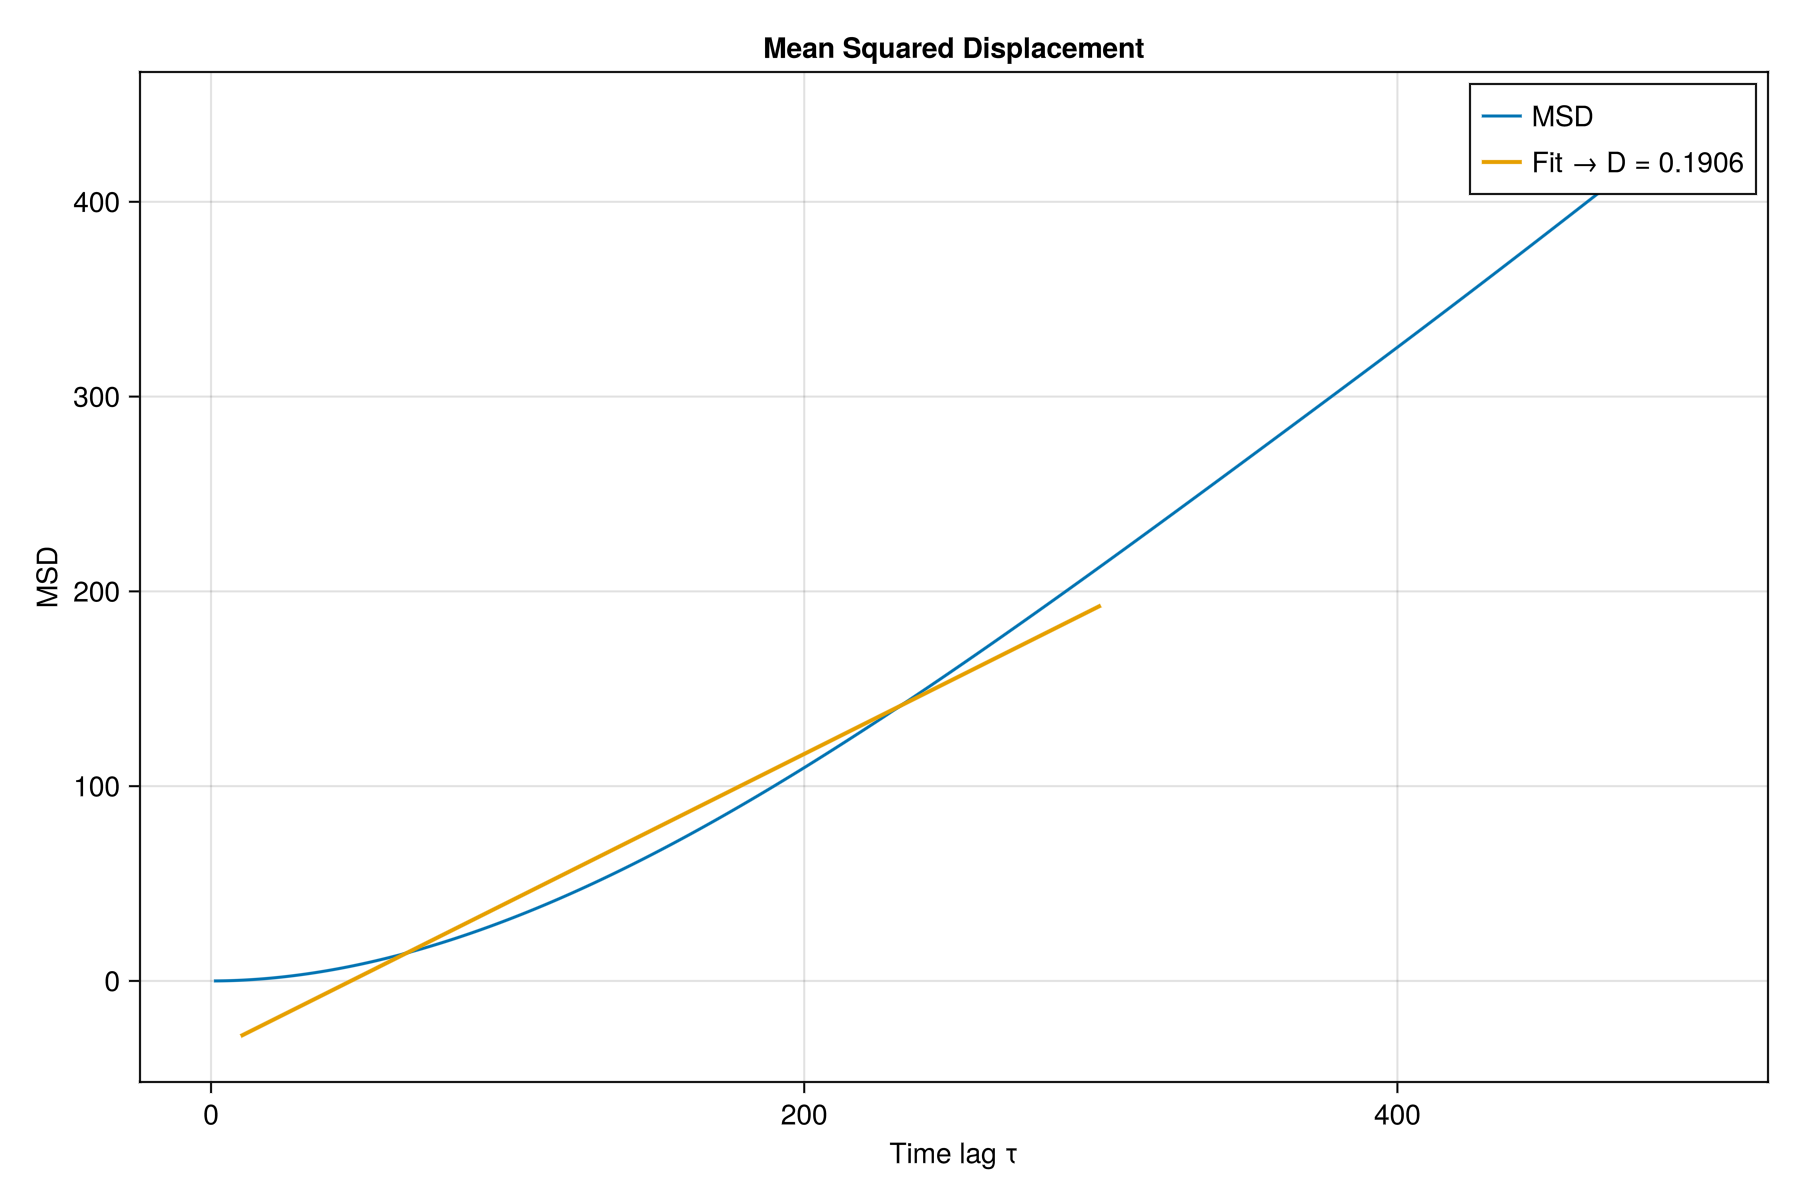

In [36]:
# ----------------------------
# USER SETTINGS
# ----------------------------
filename = "calculate_msd.jld2"
agent_id = 1          # set to nothing if you want ensemble MSD
steps = 1000          # number of saved timesteps
N = 200               # number of agents in file

use_ensemble = true   # true = average over all agents
fit_start = 10        # exclude ballistic regime
fit_end = 300         # adjust depending on your system

# ----------------------------
# LOAD TRAJECTORIES
# ----------------------------
println("Loading trajectories...")

xs = zeros(steps, N)
ys = zeros(steps, N)

jldopen("calculate_msd.jld2", "r") do file
    for t in 1:steps
        g = file[@sprintf("step_%06d", t)]
        xs[t, :] .= g["x"]
        ys[t, :] .= g["y"]
    end
end

println("Done loading.")

# ----------------------------
# COMPUTE MSD
# ----------------------------
maxlag = steps ÷ 2
msd = zeros(maxlag)

if use_ensemble
    println("Computing ensemble MSD...")

    for τ in 1:maxlag
        accum = 0.0
        count = 0

        for t in 1:(steps - τ)
            dx = xs[t + τ, :] .- xs[t, :]
            dy = ys[t + τ, :] .- ys[t, :]

            accum += mean(dx.^2 .+ dy.^2)
            count += 1
        end

        msd[τ] = accum / count
    end

else
    println("Computing single-agent MSD...")

    x0 = xs[1, agent_id]
    y0 = ys[1, agent_id]

    for τ in 1:maxlag
        msd[τ] = (xs[τ, agent_id] - x0)^2 +
                 (ys[τ, agent_id] - y0)^2
    end
end

println("MSD computed.")

# ----------------------------
# FIT DIFFUSION COEFFICIENT
# MSD = 4 D t (2D)
t = collect(1:maxlag)
fit_range = fit_start:fit_end

x = t[fit_range]
y = msd[fit_range]

slope = cov(x, y) / var(x)
intercept = mean(y) - slope * mean(x)

D = slope / 4

println("\n======================")
println("Estimated diffusion coefficient:")
println("D = ", D)
println("======================\n")

# # ----------------------------
# # PLOT WITH GLMakie
# # ----------------------------
println("Plotting...")

fig = Figure(size = (900, 600))

ax = Axis(fig[1, 1],
    xlabel = "Time lag τ",
    ylabel = "MSD",
    title = "Mean Squared Displacement"
)

lines!(ax, t, msd, label = "MSD")

# fitted line
fit_line = slope .* t .+ intercept
lines!(ax, t[fit_range], fit_line[fit_range],
    linewidth = 2,
    label = "Fit → D = $(round(D, sigdigits=4))"
)

axislegend(ax)

fig

In [38]:
save("Plots/MSD_model.png", fig)

# Drift velocity calculation

In [118]:
gradient = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    agentODE = quote  
        
        mm = 1 / (1 + exp(-30 * (x - 0)))
        M = mm

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) 
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)       

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        v_run = v
        v_tumble = 0.25 
        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble
        if active
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed 
                vy = speed 
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed 
                vy = speed 
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end

    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if ac

In [119]:
com = Community(
    gradient,
    N=100,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 10
com.delta = 0.01

com.x = 0
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K 

com.S .= 0.0
com.active = true


true

In [120]:
outfile = "calculate_vd.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=100)

jldopen(outfile, "w") do file
    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["mm"] = copy(com.M)
    end
end


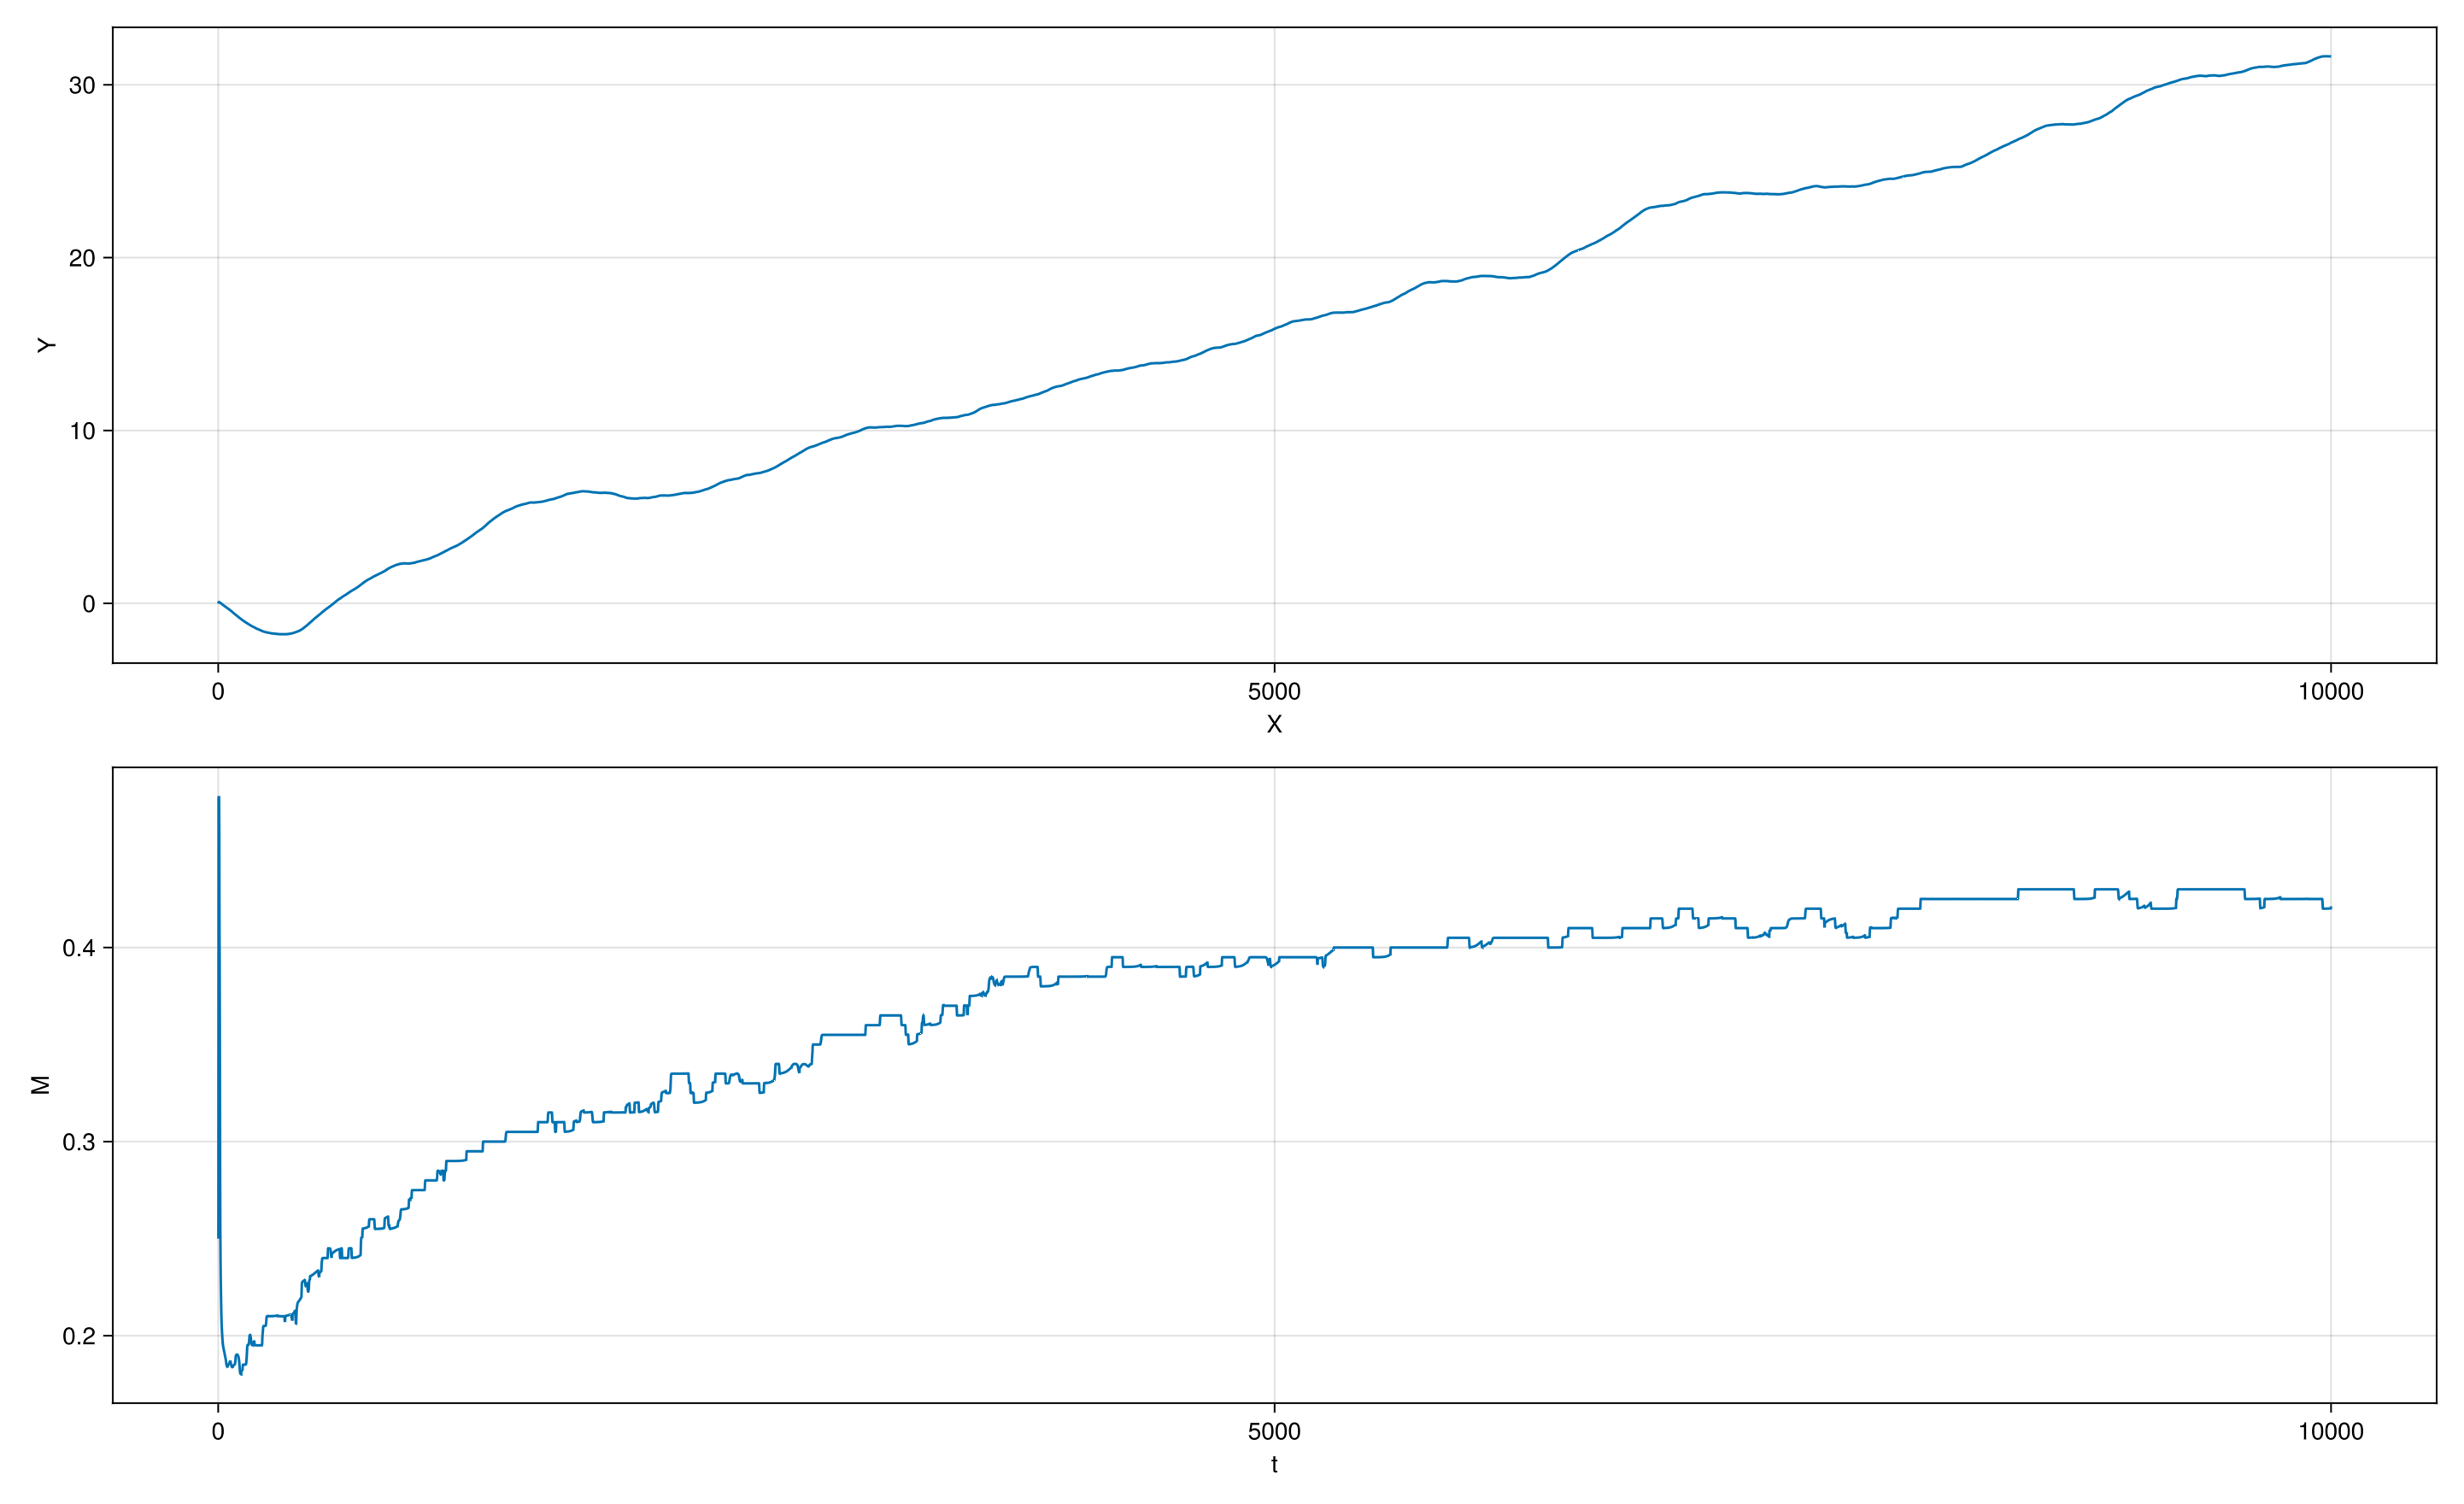

GLMakie.Screen(...)

In [122]:
fig3 = Figure(size=(1800, 900))
ax1 = Axis(fig3[1,1], xlabel="X", ylabel="Y")
ax2 = Axis(fig3[2,1], xlabel="t", ylabel="M")


steps = 10000
x = Float64[]
y = Float64[]
M = Float64[]

jldopen("calculate_vd.jld2", "r") do file 
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            x_1 = g["x"]
            y_1 = g["y"]
            mm = g["mm"]

            push!(x, mean(x_1))
            push!(y, mean(y_1))
            push!(M, mean(mm))
    

        end
    lines!(ax1, 1:steps, x)
    lines!(ax2, 1:steps, M)

end
display(fig3)

Loading trajectories...
Done loading.
Drift velocity:
vx = -0.006619954404971475
vy = 0.0004340990048512796
Speed = 0.0066341720108777785
Plotting...


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\ibzja\.julia\packages\Makie\Vn16E\src\scenes.jl:264


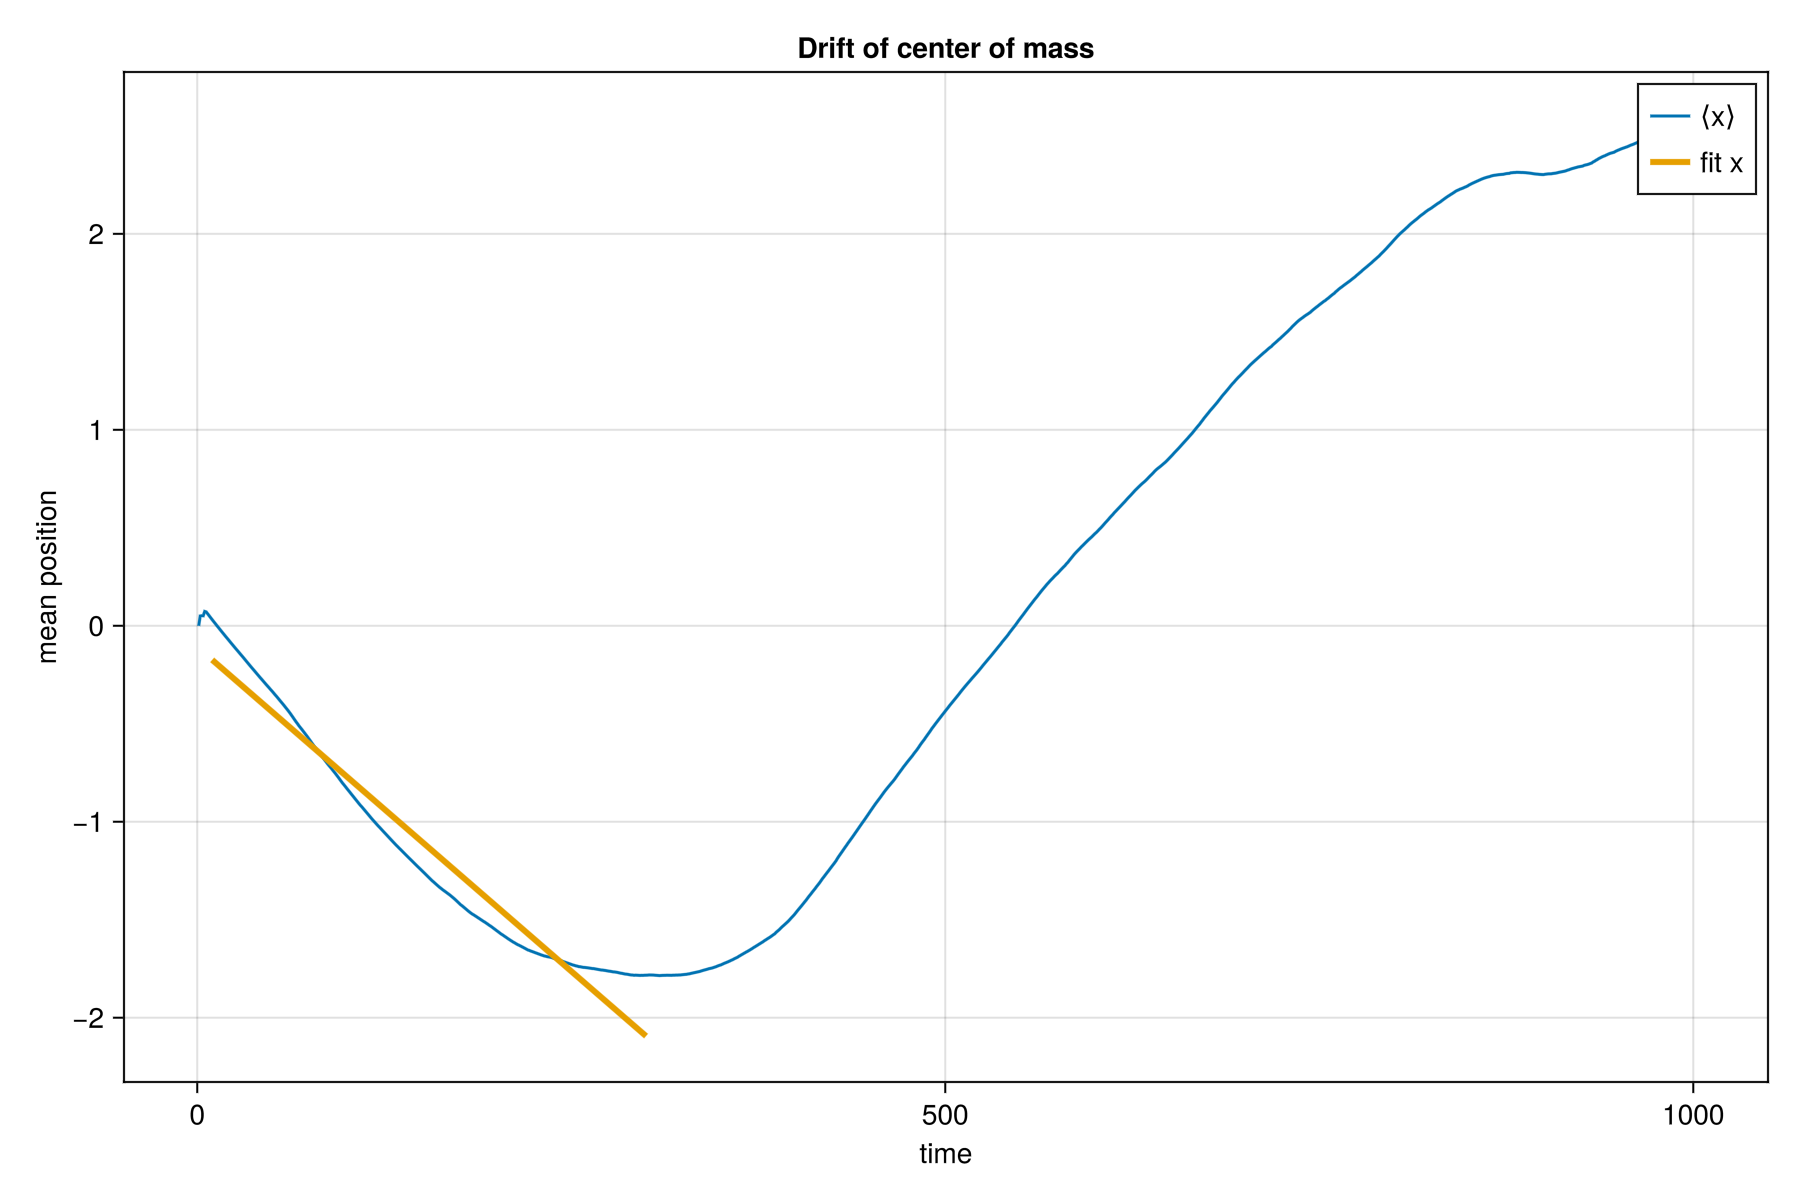

In [ ]:
# ----------------------------
# USER SETTINGS
# ----------------------------
agent_id = 1          # set to nothing if you want ensemble MSD
steps = 1000          # number of saved timesteps
N = 200               # number of agents in file

use_ensemble = true   # true = average over all agents
fit_start = 10        # exclude ballistic regime
fit_end = 300         # adjust depending on your system

# ----------------------------
# LOAD TRAJECTORIES
# ----------------------------
println("Loading trajectories...")

xs = zeros(steps, N)
ys = zeros(steps, N)

jldopen("calculate_vd.jld2", "r") do file
    for t in 1:steps
        g = file[@sprintf("step_%06d", t)]
        xs[t, :] .= g["x"]
        ys[t, :] .= g["y"]
    end
end

mean_x = mean(xs, dims=2)[:]
mean_y = mean(ys, dims=2)[:]

t = collect(1:length(mean_x))

println("Done loading.")
# Drift velocity
fit_range = fit_start:fit_end

# X direction
x_fit = t[fit_range]
mx_fit = mean_x[fit_range]

vx = cov(x_fit, mx_fit) / var(x_fit)

# Y direction
my_fit = mean_y[fit_range]
vy = cov(x_fit, my_fit) / var(x_fit)

println("Drift velocity:")
println("vx = ", vx)
println("vy = ", vy)
println("Speed = ", sqrt(vx^2 + vy^2))

# # ----------------------------
# # PLOT WITH GLMakie
# # ----------------------------
println("Plotting...")

fig = Figure(resolution = (900, 600))

ax = Axis(fig[1, 1],
    xlabel = "time",
    ylabel = "mean position",
    title = "Drift of center of mass"
)

lines!(ax, t, mean_x, label = "⟨x⟩")
# lines!(ax, t, mean_y, label = "⟨y⟩")

# fitted lines
fit_x = vx .* t .+ (mean(mean_x[fit_range]) - vx * mean(x_fit))
# fit_y = vy .* t .+ (mean(mean_y[fit_range]) - vy * mean(x_fit))

lines!(ax, t[fit_range], fit_x[fit_range], linewidth=3, label="fit x")
# lines!(ax, t[fit_range], fit_y[fit_range], linewidth=3, label="fit y")

axislegend(ax)

fig

In [127]:
bessel = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        M = mm

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        fx = vx
        fy = vy

        # dt(x) = active * vx  #Change position acording to constant speed afected by forces
        # dt(y) = active * vy  
        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        if isSource
            active = false
            x = 0
            y = 0
            vx = 0.0
            vy = 0.0

        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

        end

        # #Periodic boundry
        # xmin, xmax = simBox[1,1]*0.9, simBox[1,2]*0.9
        # ymin, ymax = simBox[2,1]*0.9, simBox[2,2]*0.9
        # # X direction
        # if x < xmin
        #     x += (xmax - xmin)
        # elseif x > xmax
        #     x -= (xmax - xmin)
        # end

        # # Y direction
        # if y < ymin
        #     y += (ymax - ymin)
        # elseif y > ymax
        #     y -= (ymax - ymin)
        # end

        #Previous boundry conditions
        # if x < simBox[1,1]*0.9
        #     x = simBox[1,1]*0.9
        #     theta = pi - theta   
        # elseif x > simBox[1,2]*0.9
        #     x = simBox[1,2]*0.9
        #     theta = pi - theta
        # end
        # if y < simBox[2,1]*0.9
        #     y = simBox[2,1]*0.9
        #     theta = -theta/2
        # elseif y > simBox[2,2]*0.9
        #     y = simBox[2,2]*0.9
        #     theta = -theta/2
        # end

    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 if isSource
    active__ = false
    x__ = 0
    y__ = 0


In [131]:
com = Community(
    bessel,
    N=100,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 10
com.delta = 0.01

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.x = 2.5*sqrt(com.DMedium/com.delta)
com.y = 2.5*sqrt(com.DMedium/com.delta)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

src = 1

com.x[src] = 0
com.y[src] = 0

com.isSource .= false
com.isSource[src] = true

com.active .= true 
com.active[src] = false   

com.S .= 0.0



100-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [132]:
outfile = "calculate_vd.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=100)

jldopen(outfile, "w") do file
    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
    end
end


Loading trajectories...
Done loading.
Drift velocity:
vx = 0.001586473448346992
vy = 0.0021710303486440013
Speed = 0.002688916283011297
Plotting...


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\ibzja\.julia\packages\Makie\Vn16E\src\scenes.jl:264


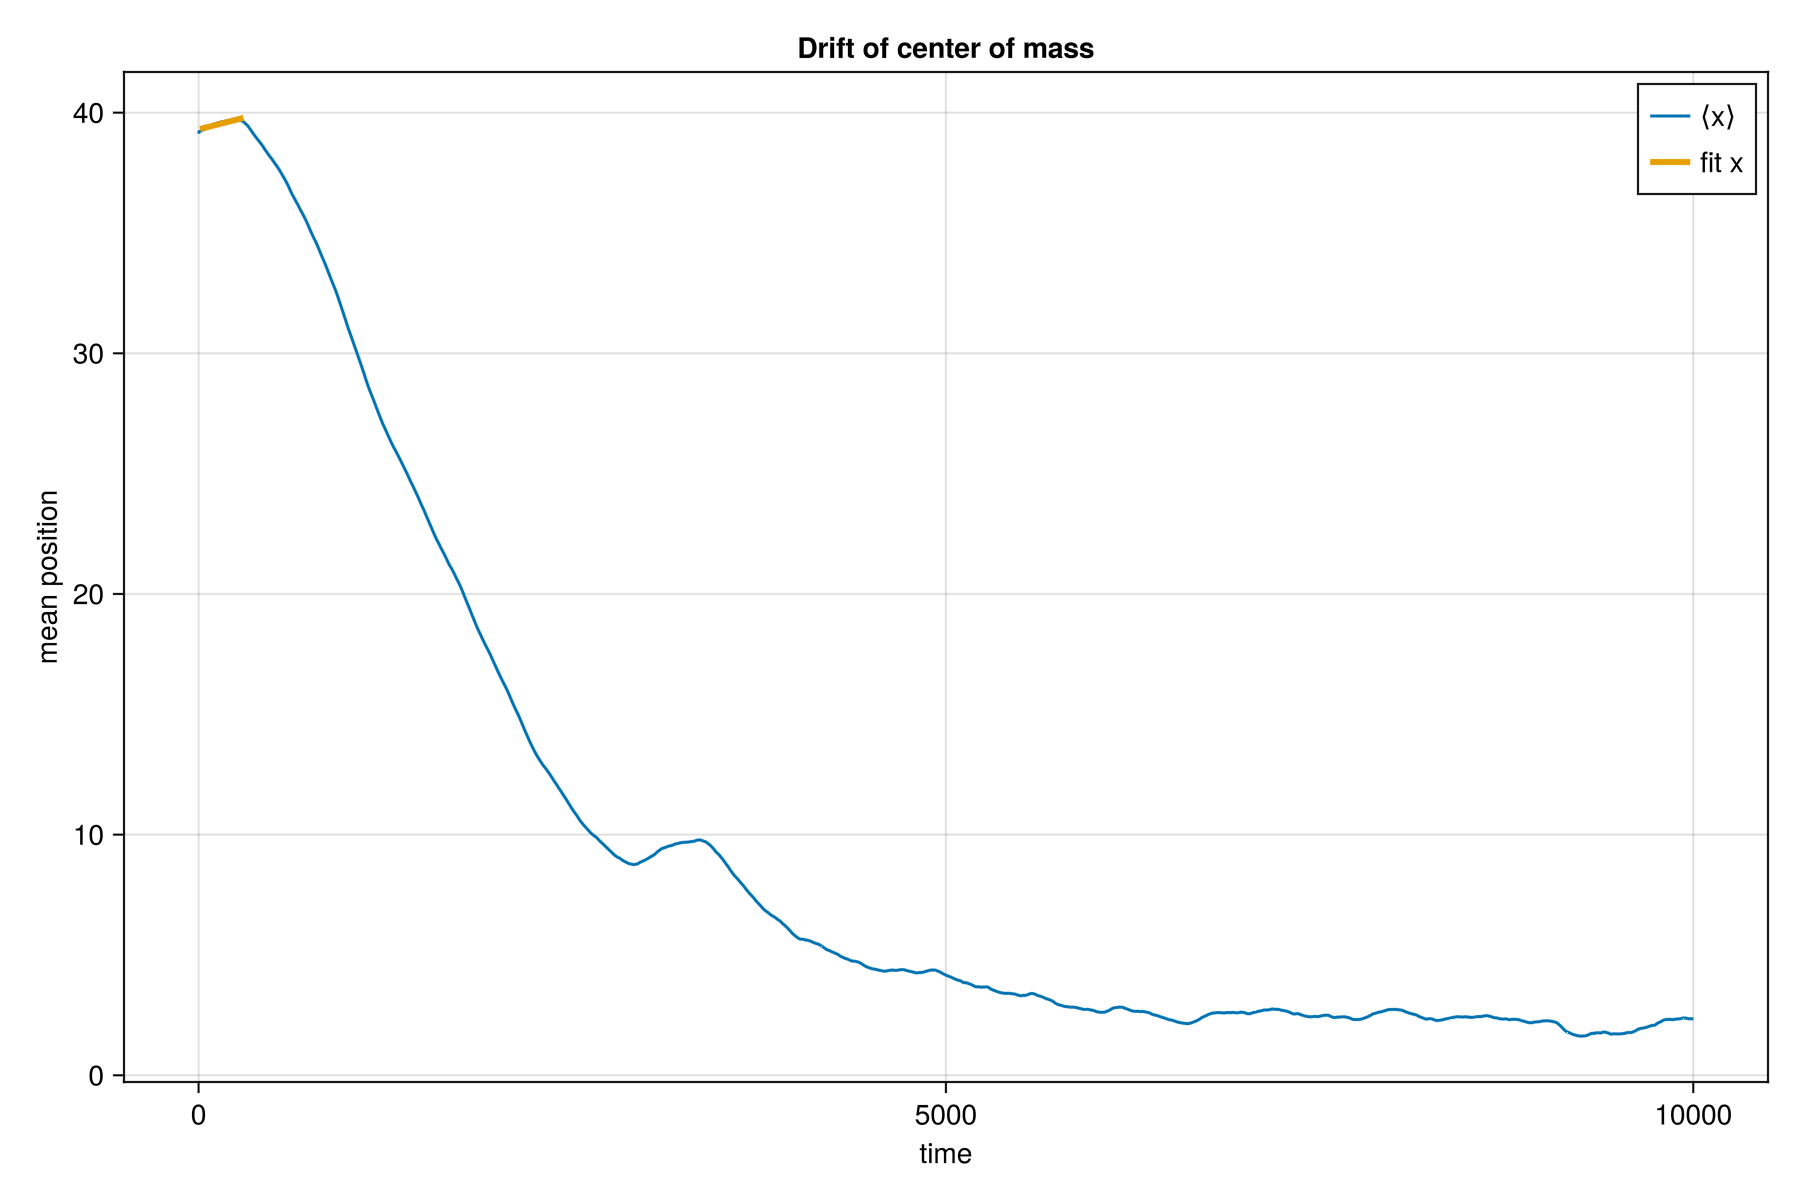

In [134]:
# ----------------------------
# USER SETTINGS
# ----------------------------
agent_id = 1          # set to nothing if you want ensemble MSD
steps = 10000          # number of saved timesteps
N = 200               # number of agents in file

use_ensemble = true   # true = average over all agents
fit_start = 10        # exclude ballistic regime
fit_end = 300         # adjust depending on your system

# ----------------------------
# LOAD TRAJECTORIES
# ----------------------------
println("Loading trajectories...")

xs = zeros(steps, N)
ys = zeros(steps, N)

jldopen("calculate_vd.jld2", "r") do file
    for t in 1:steps
        g = file[@sprintf("step_%06d", t)]
        xs[t, :] .= g["x"]
        ys[t, :] .= g["y"]
    end
end

mean_x = mean(xs, dims=2)[:]
mean_y = mean(ys, dims=2)[:]

t = collect(1:length(mean_x))

println("Done loading.")
# Drift velocity
fit_range = fit_start:fit_end

# X direction
x_fit = t[fit_range]
mx_fit = mean_x[fit_range]

vx = cov(x_fit, mx_fit) / var(x_fit)

# Y direction
my_fit = mean_y[fit_range]
vy = cov(x_fit, my_fit) / var(x_fit)

println("Drift velocity:")
println("vx = ", vx)
println("vy = ", vy)
println("Speed = ", sqrt(vx^2 + vy^2))

# # ----------------------------
# # PLOT WITH GLMakie
# # ----------------------------
println("Plotting...")

fig = Figure(resolution = (900, 600))

ax = Axis(fig[1, 1],
    xlabel = "time",
    ylabel = "mean position",
    title = "Drift of center of mass"
)

lines!(ax, t, mean_x, label = "⟨x⟩")
# lines!(ax, t, mean_y, label = "⟨y⟩")

# fitted lines
fit_x = vx .* t .+ (mean(mean_x[fit_range]) - vx * mean(x_fit))
# fit_y = vy .* t .+ (mean(mean_y[fit_range]) - vy * mean(x_fit))

lines!(ax, t[fit_range], fit_x[fit_range], linewidth=3, label="fit x")
# lines!(ax, t[fit_range], fit_y[fit_range], linewidth=3, label="fit y")

axislegend(ax)

fig

Loading trajectories...
Done loading.
Computing gradients...
Using 296901 samples after filtering.

Chemotactic sensitivity χ:
χ = 10.615977019687243

Plotting...


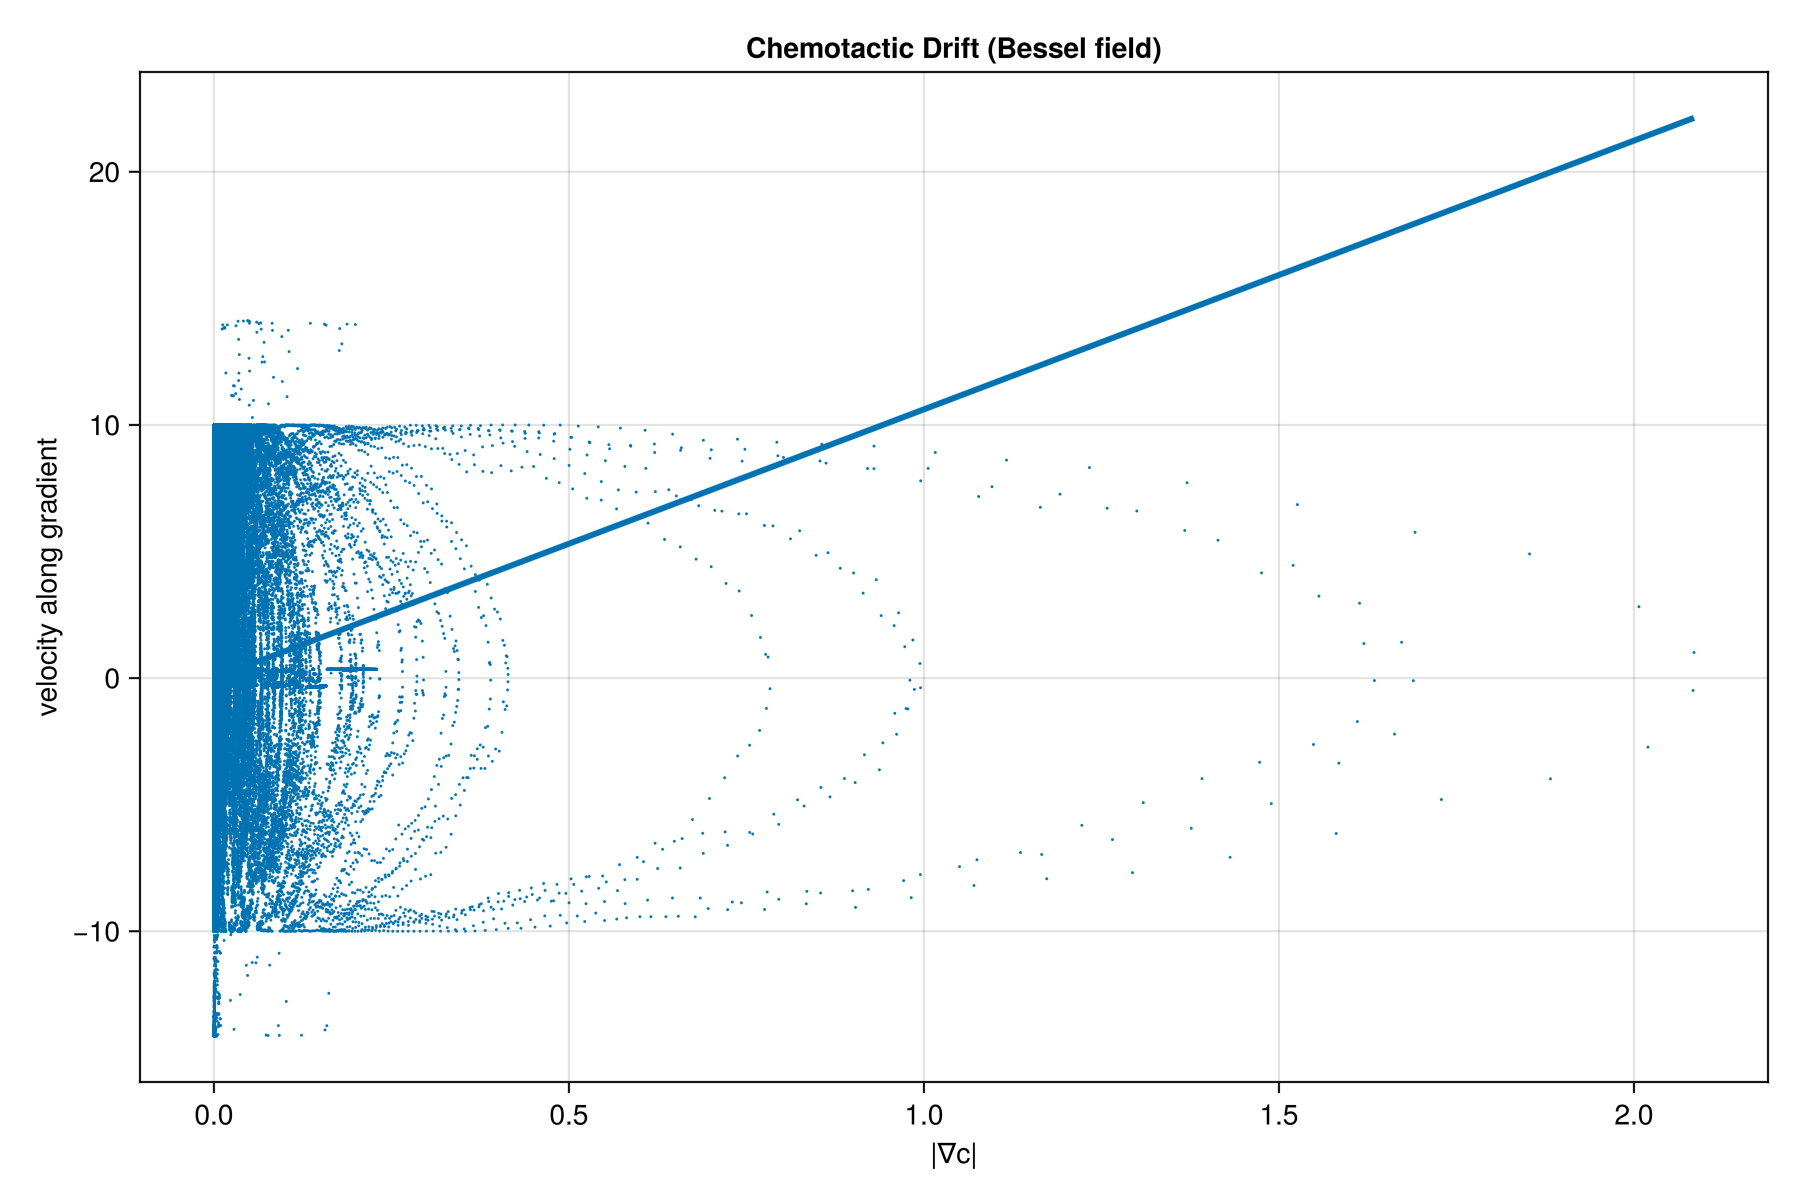

In [138]:

# ----------------------------
# USER SETTINGS
# ----------------------------
filename = "calculate_vd.jld2"
steps = 10000
N = 200
dt = 0.01

# chemical field parameters
Dc = 10.0
delta = 0.01
ll = sqrt(Dc / delta)

# cutoff to avoid singularity
r_min = 1e-6

# ----------------------------
# LOAD TRAJECTORIES
# ----------------------------
println("Loading trajectories...")

xs = zeros(steps, N)
ys = zeros(steps, N)

jldopen(filename, "r") do file
    for t in 1:steps
        g = file[@sprintf("step_%06d", t)]
        xs[t, :] .= g["x"]
        ys[t, :] .= g["y"]
    end
end

println("Done loading.")
tmax = Int(0.3 * steps)   # use first 30% of trajectory

vx = (xs[2:tmax, :] .- xs[1:tmax-1, :]) ./ dt
vy = (ys[2:tmax, :] .- ys[1:tmax-1, :]) ./ dt

x_all = vec(xs[1:tmax-1, :])
y_all = vec(ys[1:tmax-1, :])


# flatten
vx_all = vec(vx)
vy_all = vec(vy)

# ----------------------------
# Bessel FIELD GRADIENT
# c(r) = K0(r/ll)
# ∇c = -(1/ll) K1(r/ll) r̂
# ----------------------------
function grad_c(x, y)
    r = sqrt(x^2 + y^2)

    if r < r_min
        return 0.0, 0.0
    end

    factor = -(1 / ll) * besselk(1, r / ll)

    dc_dx = factor * (x / r)
    dc_dy = factor * (y / r)

    return dc_dx, dc_dy
end

println("Computing gradients...")

gx = similar(x_all)
gy = similar(y_all)

for i in eachindex(x_all)
    gx[i], gy[i] = grad_c(x_all[i], y_all[i])
end

# ----------------------------
# FILTER OUT VERY SMALL GRADIENTS (important!)
# ----------------------------
grad_mag = sqrt.(gx.^2 .+ gy.^2)
mask = grad_mag .> 1e-6

vx_f = vx_all[mask]
vy_f = vy_all[mask]
gx_f = gx[mask]
gy_f = gy[mask]

println("Using $(length(vx_f)) samples after filtering.")

# ----------------------------
# ESTIMATE χ (vector formula)
# χ = <v · ∇c> / <|∇c|²>
# ----------------------------
numerator = mean(vx_f .* gx_f .+ vy_f .* gy_f)
denominator = mean(gx_f.^2 .+ gy_f.^2)

χ = numerator / denominator

println("\n======================")
println("Chemotactic sensitivity χ:")
println("χ = ", χ)
println("======================\n")

# ----------------------------
# VISUALIZATION
# ----------------------------
println("Plotting...")

fig = Figure(size = (900, 600))

ax = Axis(fig[1,1],
    xlabel = "|∇c|",
    ylabel = "velocity along gradient",
    title = "Chemotactic Drift (Bessel field)"
)

# projection of velocity onto gradient direction
v_parallel = (vx_f .* gx_f .+ vy_f .* gy_f) ./ (sqrt.(gx_f.^2 .+ gy_f.^2) .+ 1e-12)

scatter!(ax, sqrt.(gx_f.^2 .+ gy_f.^2), v_parallel, markersize = 2)

# expected linear relation: v = χ |∇c|
xfit = range(minimum(sqrt.(gx_f.^2 .+ gy_f.^2)),
             maximum(sqrt.(gx_f.^2 .+ gy_f.^2)),
             length=200)

lines!(ax, xfit, χ .* xfit, linewidth = 3)

fig